Nama: Yuda
NIM: 240401010353

In [14]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign
print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [16]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
coef_df = pd.DataFrame({'Fitur': X.columns,
 'Koefisien': log_model.coef_[0]}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
tree_model = DecisionTreeClassifier(max_depth=4,
 random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

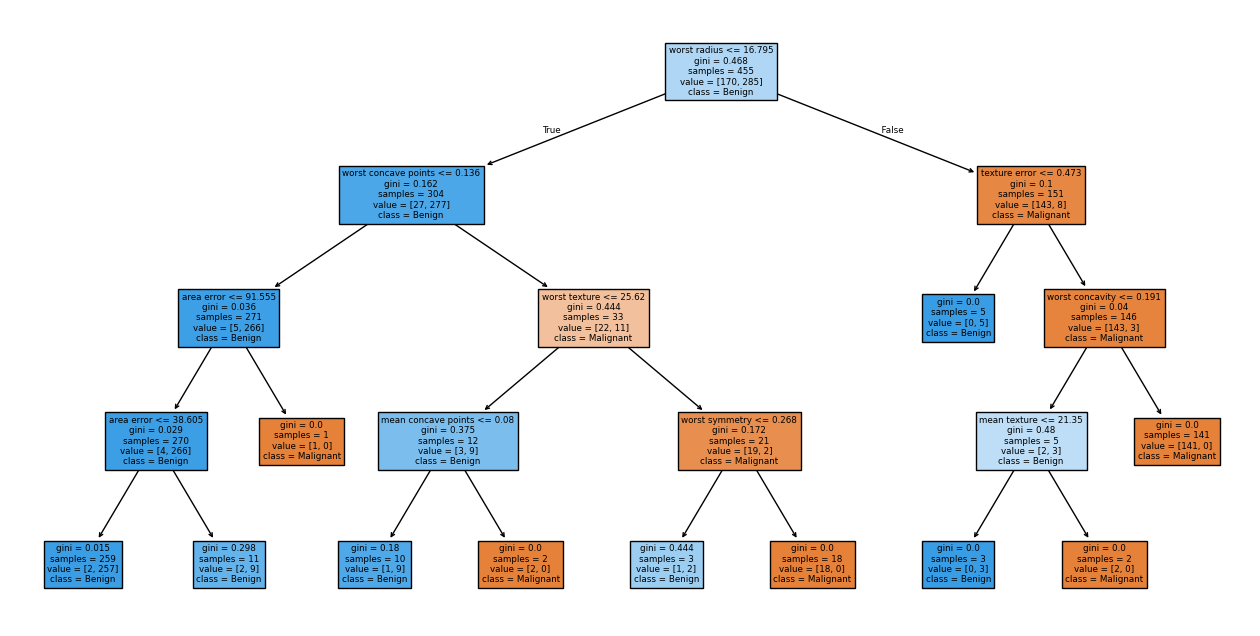

In [18]:
plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
 class_names=['Malignant','Benign'], filled=True)
plt.show()


In [19]:
from sklearn.metrics import (confusion_matrix,
 accuracy_score, precision_score,
 recall_score, f1_score)
for name, y_pred in [('Logistic Regression', y_pred_log),
 ('Decision Tree', y_pred_tree)]:
 print(f"\n=== {name} ===")
 print(confusion_matrix(y_test, y_pred))
 print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
 print(f"Precision: {precision_score(y_test, y_pred):.3f}")
 print(f"Recall : {recall_score(y_test, y_pred):.3f}")
 print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")



=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall : 0.944
F1-Score : 0.951
